Hermann Hesse - Steppenwolf: 75864 words
Franz Kafka - Metamorphosis: 22377 words
Fyodor Dostoevsky - Notes from the Underground: 44733 words
Hermann Hesse - Siddhartha: 39799 words
Franz Kafka - The Trial: 84327 words
Fyodor Dostoevsky - Crime and Punishment: 209022 words
Friedrich Nietzsche - Thus Spake Zarathustra: 113582 words

Frequency per 1,000 words:
theme                death  freedom  anxiety  absurd  solitude
author                                                        
Franz Kafka           0.12     0.57     0.38    0.04      0.23
Friedrich Nietzsche   1.70     0.76     0.34    0.05      0.86
Fyodor Dostoevsky     0.86     0.35     0.96    0.46      0.47
Hermann Hesse         1.64     0.25     0.77    0.10      0.82


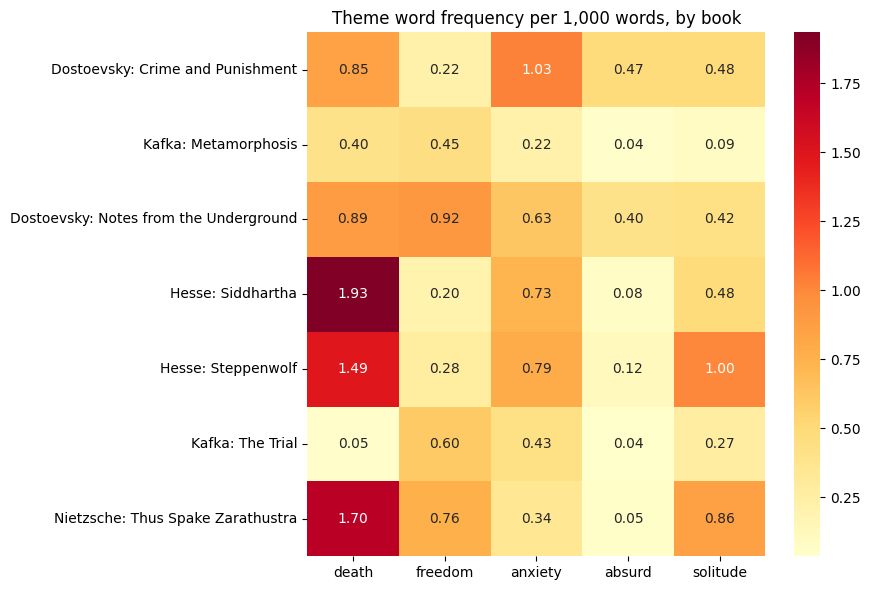

In [8]:
import random
import requests, re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

BOOKS = [
    ("Hermann Hesse", "Steppenwolf", 75756),
    ("Franz Kafka", "Metamorphosis", 5200),
    ("Fyodor Dostoevsky", "Notes from the Underground", 600),
    ("Hermann Hesse", "Siddhartha", 2500),
    ("Franz Kafka", "The Trial", 7849),
    ("Fyodor Dostoevsky", "Crime and Punishment", 2554),
    ("Friedrich Nietzsche", "Thus Spake Zarathustra", 1998),
]

THEMES = {
    "death":    ["death", "die", "died", "dying", "dead", "grave", "corpse"],
    "freedom":  ["free", "freedom", "liberty", "choice", "choose"],
    "anxiety":  ["anxiety", "dread", "fear", "terror", "afraid", "anguish"],
    "absurd":   ["absurd", "meaningless", "senseless", "nonsense", "futile"],
    "solitude": ["alone", "lonely", "solitude", "isolation", "loneliness"],
}


def load_book(book_id):
    url = f"https://www.gutenberg.org/cache/epub/{book_id}/pg{book_id}.txt"
    r = requests.get(url)
    r.raise_for_status()
    text = r.text
    start = re.search(r"\*\*\* ?START OF.*?\*\*\*", text)
    end = re.search(r"\*\*\* ?END OF.*?\*\*\*", text)
    if start and end:
        text = text[start.end():end.start()]
    return re.findall(r"[a-z']+", text.lower())


corpus = {}
rows = []

for author, title, book_id in BOOKS:
    try:
        words = load_book(book_id)
    except Exception as e:
        print(f"Could not download {title} ({book_id}): {e}")
        continue
    corpus[title] = words
    print(f"{author} - {title}: {len(words)} words")
    for theme, keys in THEMES.items():
        count = sum(words.count(k) for k in keys)
        rows.append({"author": author, "title": title, "theme": theme,
                     "count": count, "total_words": len(words)})

df = pd.DataFrame(rows)

by_author = df.groupby(["author", "theme"]).agg(
    count=("count", "sum"),
    total_words=("total_words", "sum")
).reset_index()
by_author["per_1000"] = by_author["count"] / by_author["total_words"] * 1000

table = by_author.pivot(index="author", columns="theme", values="per_1000")
table = table[list(THEMES.keys())]
print("\nFrequency per 1,000 words:")
print(table.round(2))

df["per_1000"] = df["count"] / df["total_words"] * 1000
per_book = df.pivot(index="title", columns="theme", values="per_1000")[list(THEMES.keys())]

labels = {t: f"{a.split()[-1]}: {t}" for a, t, _ in BOOKS}
per_book_plot = per_book.rename(index=labels)

plt.figure(figsize=(9, 6))
sns.heatmap(per_book_plot, annot=True, fmt=".2f", cmap="YlOrRd")
plt.title("Theme word frequency per 1,000 words, by book")
plt.ylabel("")
plt.xlabel("")
plt.tight_layout()
plt.savefig("heatmap_books.png", dpi=200)
plt.show()


def kwic(word, title, n=5, window=8, seed=1):
    words = corpus[title]
    idx = [i for i, w in enumerate(words) if w == word]
    random.seed(seed)
    for i in random.sample(idx, min(n, len(idx))):
        print("...", " ".join(words[max(0, i - window): i + window + 1]), "...")
    print()

3929 chunks


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/123 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


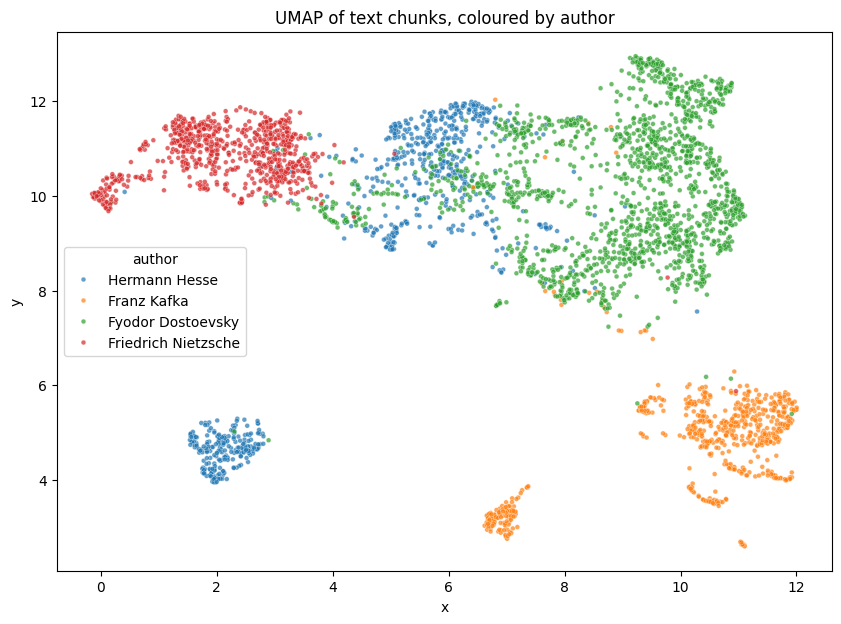

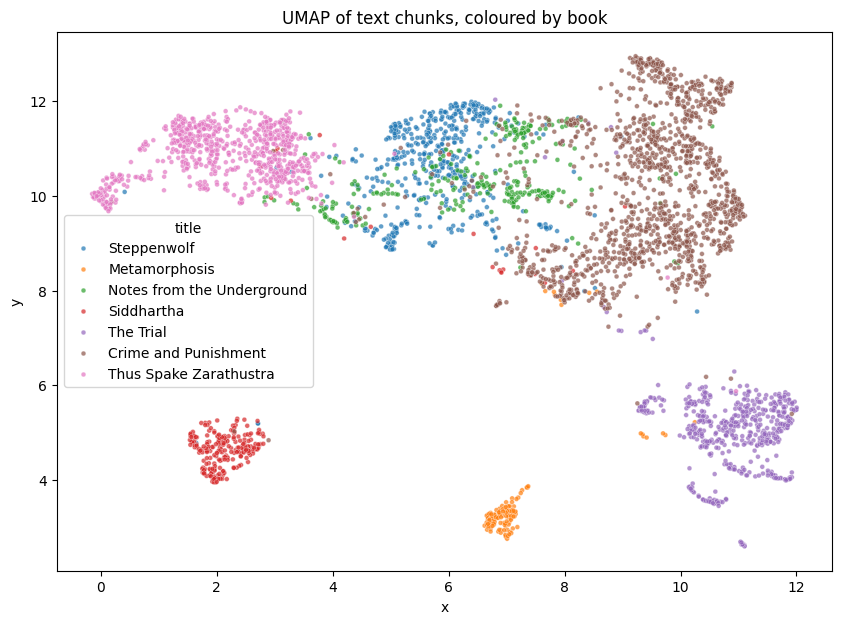

In [9]:
!pip install -q sentence-transformers umap-learn

from sentence_transformers import SentenceTransformer
import umap

# Split each book into chunks of 150 words
# (the model reads ~256 tokens, so longer chunks would be cut off)
CHUNK = 150
author_of = {t: a for a, t, _ in BOOKS}
chunk_rows = []
for title, words in corpus.items():
    for i in range(0, len(words) - CHUNK + 1, CHUNK):
        chunk_rows.append({"author": author_of[title], "title": title,
                           "text": " ".join(words[i:i + CHUNK])})
chunks = pd.DataFrame(chunk_rows)
print(len(chunks), "chunks")

# Embeddings
model = SentenceTransformer("all-MiniLM-L6-v2")
emb = model.encode(chunks["text"].tolist(), show_progress_bar=True)

# 2D map
xy = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(emb)
chunks["x"], chunks["y"] = xy[:, 0], xy[:, 1]

# Plot 1: colour by author
plt.figure(figsize=(10, 7))
sns.scatterplot(data=chunks, x="x", y="y", hue="author", s=12, alpha=0.7)
plt.title("UMAP of text chunks, coloured by author")
plt.savefig("umap_authors.png", dpi=200)
plt.show()

# Plot 2: colour by book
plt.figure(figsize=(10, 7))
sns.scatterplot(data=chunks, x="x", y="y", hue="title", s=12, alpha=0.7)
plt.title("UMAP of text chunks, coloured by book")
plt.savefig("umap_books.png", dpi=200)
plt.show()

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score

mask = (chunks["author"] != "Friedrich Nietzsche").values
data = chunks[mask].reset_index(drop=True)
X = emb[mask]
y = data["author"]

def run(train_books, test_books):
    tr = data["title"].isin(train_books).values
    te = data["title"].isin(test_books).values
    clf = LogisticRegression(max_iter=1000).fit(X[tr], y[tr])
    return balanced_accuracy_score(y[te], clf.predict(X[te]))

set_a = ["Steppenwolf", "Metamorphosis", "Notes from the Underground"]
set_b = ["Siddhartha", "The Trial", "Crime and Punishment"]

print("train A -> test B:", round(run(set_a, set_b), 2))
print("train B -> test A:", round(run(set_b, set_a), 2))
print("chance level: 0.33")

train A -> test B: 0.59
train B -> test A: 0.4
chance level: 0.33


In [11]:
df["per_1000"] = df["count"] / df["total_words"] * 1000
per_book = df.pivot(index="title", columns="theme", values="per_1000")[list(THEMES.keys())]
print(per_book.round(2))


theme                       death  freedom  anxiety  absurd  solitude
title                                                                
Crime and Punishment         0.85     0.22     1.03    0.47      0.48
Metamorphosis                0.40     0.45     0.22    0.04      0.09
Notes from the Underground   0.89     0.92     0.63    0.40      0.42
Siddhartha                   1.93     0.20     0.73    0.08      0.48
Steppenwolf                  1.49     0.28     0.79    0.12      1.00
The Trial                    0.05     0.60     0.43    0.04      0.27
Thus Spake Zarathustra       1.70     0.76     0.34    0.05      0.86
